# Figure 4C-G: Delta-average comparison

Reproduces the Jiang24 delta-average comparison and true-delta similarity diagnostic panels.


In [1]:
# Set to True to write image files to figures/main/output/.
SAVE_FIGURES = False

## Delta-average benchmark summary


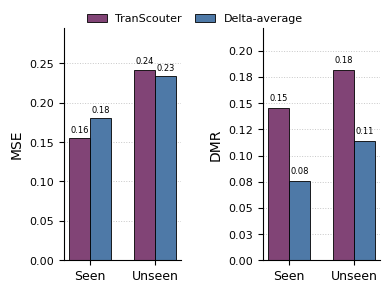

In [2]:
import os
import pickle
from pathlib import Path


ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
OUT_DIR = ROOT / "figures" / "main" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUT_DIR / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(OUT_DIR / ".cache"))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

os.chdir(ROOT)

PLOT_DATA = ROOT / "results" / "baselines" / "delta_average" / "delta_avg_compare_plot_data.pkl"
OUT_PNG = OUT_DIR / "jiang24_delta_average_summary.png"

SCENARIO_LABELS = {
    "Jiang24 Seen Perturbation": "Seen",
    "Jiang24 Unseen Perturbation": "Unseen",
}
METHODS = ["TranScouter", "DeltaAverage"]
METHOD_LABELS = {"TranScouter": "TranScouter", "DeltaAverage": "Delta-average"}
COLORS = {
    "TranScouter": "#814476",  # Matches the Jiang plotting palette.
    "DeltaAverage": "#4E79A7",
}


def main():
    with open(PLOT_DATA, "rb") as f:
        data = pickle.load(f)
    overall = data["overall_summary"]
    overall = overall[
        overall["scenario"].isin(SCENARIO_LABELS) & overall["method"].isin(METHODS)
    ].copy()

    fig, axes = plt.subplots(1, 2, figsize=(4.0, 3.0))
    metrics = [("MSE_degs", "MSE"), ("DMR_degs", "DMR")]
    group_x = np.arange(len(SCENARIO_LABELS))
    width = 0.32

    for ax, (metric, ylabel) in zip(axes, metrics):
        ymax = 0
        for method_i, method in enumerate(METHODS):
            values = []
            for scenario in SCENARIO_LABELS:
                value = overall[
                    (overall["scenario"] == scenario) & (overall["method"] == method)
                ][metric].iloc[0]
                values.append(value)
            xpos = group_x + (method_i - 0.5) * width
            bars = ax.bar(
                xpos,
                values,
                width=width,
                label=METHOD_LABELS[method],
                color=COLORS[method],
                edgecolor="black",
                linewidth=0.6,
            )
            ymax = max(ymax, max(values))
            for bar, value in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 0.005,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=6,
                )

        ax.set_xticks(group_x)
        ax.set_xticklabels(list(SCENARIO_LABELS.values()), fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_ylim(0, ymax * 1.22)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax.set_axisbelow(True)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.tick_params(axis="y", labelsize=8)

    fig.tight_layout(rect=(0, 0, 1, 0.95), w_pad=2.0)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=2,
        columnspacing=1.2,
        handlelength=1.8,
    )
    if globals().get("SAVE_FIGURES", False):
        fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
        print(f"Saved: {OUT_PNG}")
    plt.show()


if __name__ == "__main__":
    main()


## True-delta similarity diagnostics


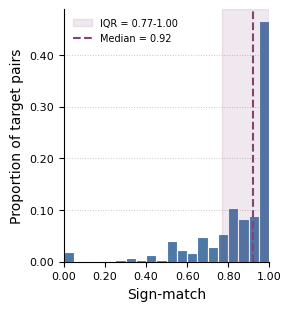

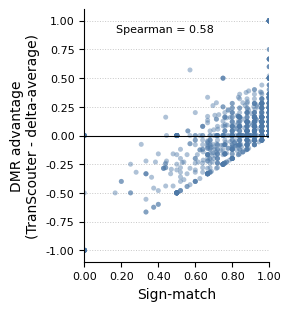

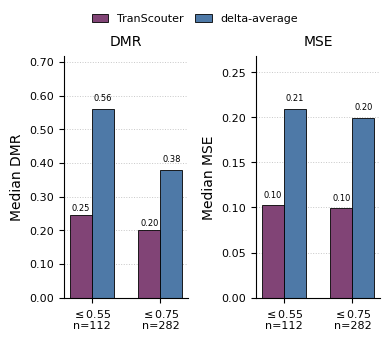

In [3]:
import os
import pickle
from pathlib import Path


ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
OUT_DIR = ROOT / "figures" / "main" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUT_DIR / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(OUT_DIR / ".cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


IN_CSV = ROOT / "results" / "baselines" / "delta_average" / "diagnosis_true_delta_similarity.csv"
PLOT_DATA = ROOT / "results" / "baselines" / "delta_average" / "delta_avg_compare_plot_data.pkl"

OUT_HIST = OUT_DIR / "jiang24_sign_match_histogram.png"
OUT_SCATTER = OUT_DIR / "jiang24_sign_match_advantage_scatter.png"
OUT_STRATIFIED = OUT_DIR / "jiang24_sign_match_stratified_bars.png"

METHODS = ["TranScouter", "DeltaAverage"]
METHOD_LABELS = {"TranScouter": "TranScouter", "DeltaAverage": "delta-average"}
COLORS = {
    "TranScouter": "#814476",  # Matches the Jiang plotting palette.
    "DeltaAverage": "#4E79A7",
}


def fmt2(value):
    return f"{float(value) + 1e-9:.2f}"


# Load sign-match diagnostics and attach MSE values for the same target pairs.
df = pd.read_csv(IN_CSV)
with open(PLOT_DATA, "rb") as f:
    plot_data = pickle.load(f)

condition_metrics = plot_data["condition_metrics"]
sub = condition_metrics[
    condition_metrics["scenario"].str.startswith("Jiang24")
    & condition_metrics["method"].isin(METHODS)
]
mse_wide = (
    sub.pivot_table(
        index=["scenario", "cov_pert"],
        columns="method",
        values="MSE_degs",
        aggfunc="first",
    )
    .reset_index()
    .rename(
        columns={
            "TranScouter": "TranScouter_MSE",
            "DeltaAverage": "DeltaAverage_MSE",
        }
    )
)
df = df.merge(mse_wide, on=["scenario", "cov_pert"], how="inner")

x = df["avg_delta_sign_match"]
y = df["delta_advantage"]
median = x.median()
q25 = x.quantile(0.25)
q75 = x.quantile(0.75)
finite = x.notna() & y.notna()
rho = x[finite].corr(y[finite], method="spearman")


# Figure 1: sign-match histogram.
fig, ax = plt.subplots(figsize=(2.8, 3.0), constrained_layout=True)
bins = np.linspace(0, 1, 21)
weights = np.ones(len(x)) / len(x)
ax.hist(
    x,
    bins=bins,
    weights=weights,
    color=COLORS["DeltaAverage"],
    edgecolor="white",
    linewidth=0.8,
)
ax.axvspan(
    q25,
    q75,
    color=COLORS["TranScouter"],
    alpha=0.12,
    label=f"IQR = {fmt2(q25)}-{fmt2(q75)}",
)
ax.axvline(
    median,
    color=COLORS["TranScouter"],
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {fmt2(median)}",
)
ax.set_xlabel("Sign-match", fontsize=10)
ax.set_ylabel("Proportion of target pairs", fontsize=10)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(labelsize=8)
ax.legend(frameon=False, fontsize=7, loc="upper left")
if globals().get("SAVE_FIGURES", False):
    fig.savefig(OUT_HIST, dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_HIST}")
plt.show()
plt.close(fig)


# Figure 2: sign-match versus DMR advantage.
fig, ax = plt.subplots(figsize=(2.8, 3.0), constrained_layout=True)
ax.scatter(
    x,
    y,
    s=13,
    alpha=0.45,
    color=COLORS["DeltaAverage"],
    edgecolors="none",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Sign-match", fontsize=10)
ax.set_ylabel("DMR advantage\n(TranScouter - delta-average)", fontsize=10)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(labelsize=8)
ax.text(
    0.17,
    0.94,
    f"Spearman = {fmt2(rho)}",
    transform=ax.transAxes,
    fontsize=8,
    ha="left",
    va="top",
)
if globals().get("SAVE_FIGURES", False):
    fig.savefig(OUT_SCATTER, dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_SCATTER}")
plt.show()
plt.close(fig)


# Figure 3: DMR and MSE in low-sign-match subsets.
thresholds = [(0.55, r"$\leq$0.55"), (0.75, r"$\leq$0.75")]
group_x = np.arange(len(thresholds))
width = 0.32

fig, axes = plt.subplots(1, 2, figsize=(4, 3.8))
for ax, metric, ylabel, title in zip(
    axes,
    ["DMR", "MSE"],
    ["Median DMR", "Median MSE"],
    ["DMR", "MSE"],
):
    ymax = 0
    for method_i, method in enumerate(METHODS):
        values = []
        for cutoff, _ in thresholds:
            low_match = df[df["avg_delta_sign_match"] <= cutoff]
            values.append(float(low_match[f"{method}_{metric}"].median()))

        xpos = group_x + (method_i - 0.5) * width
        bars = ax.bar(
            xpos,
            values,
            width=width,
            color=COLORS[method],
            edgecolor="black",
            linewidth=0.6,
            label=METHOD_LABELS[method],
        )
        ymax = max(ymax, max(values))
        offset = max(ymax * 0.035, 0.006)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + offset,
                fmt2(value),
                ha="center",
                va="bottom",
                fontsize=6,
            )

    xticklabels = []
    for cutoff, label in thresholds:
        low_match = df[df["avg_delta_sign_match"] <= cutoff]
        xticklabels.append(f"{label}\nn={len(low_match)}")

    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xticks(group_x)
    ax.set_xticklabels(xticklabels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, ymax * 1.28)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.86), w_pad=1.0)
fig.legend(
    handles,
    labels,
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),
    ncol=2,
    columnspacing=1.0,
    handlelength=1.5,
)
if globals().get("SAVE_FIGURES", False):
    fig.savefig(OUT_STRATIFIED, dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_STRATIFIED}")
plt.show()
plt.close(fig)